# Part 2: Soft Target Knowledge Distillation 구현

## 이 노트북에서 다루는 내용
1. Soft Target KD의 핵심 개념
2. Temperature 파라미터의 역할
3. KD Loss 함수 구현
4. Student 모델 학습 (with Teacher's knowledge)
5. Baseline과 성능 비교

---

## Soft Target Knowledge Distillation 개념

### 기존 학습
```
L = CrossEntropy(student_output, hard_labels)
```

### KD 학습
```
L = α * KD_loss + (1-α) * CE_loss
```

여기서:
- `soft_teacher = softmax(teacher_logits / T)`
- `soft_student = log_softmax(student_logits / T)`
- `KD_loss = KL_divergence(soft_teacher, soft_student) * T²`

### Temperature (T) 역할
- **T=1**: 일반 softmax (sharp distribution)
- **T>1**: 더 부드러운 분포 (soft distribution)
- T가 클수록 작은 확률값들도 의미있게 전달됨

### T² 스케일링 이유
- Temperature로 나누면 gradient가 1/T²로 스케일됨
- T²를 곱해서 gradient 크기를 보정

### 핵심 통찰
- Teacher의 **"dark knowledge"** = 틀린 클래스에 대한 확률 분포
- 예: 고양이 이미지에서 `[고양이: 0.9, 호랑이: 0.05, 개: 0.03, ...]`
- 이 분포가 **클래스 간 유사도 정보**를 담고 있음

## 1. 환경 설정 및 라이브러리 Import

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 모듈에서 모델 import
from module.models import DeepNN, LightNN

In [2]:
def get_device() -> str:
    """사용 가능한 가속기 확인"""
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = get_device()
print(f"Using device: {DEVICE}")

# 하이퍼파라미터
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10

# Knowledge Distillation 하이퍼파라미터
TEMPERATURE = 2.0  # Soft target temperature
SOFT_TARGET_LOSS_WEIGHT = 0.25  # α for KD loss
CE_LOSS_WEIGHT = 0.75  # (1-α) for CE loss

# 재현성
SEED = 42
torch.manual_seed(SEED)

Using device: cuda


## 2. 데이터 로드

In [3]:
def get_data_loaders(batch_size: int = 128) -> tuple[DataLoader, DataLoader]:
    """CIFAR-10 데이터셋 로드"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])
    
    train_dataset = datasets.CIFAR10(
        root='./data/datasets', train=True, download=True, transform=transform
    )
    test_dataset = datasets.CIFAR10(
        root='./data/datasets', train=False, download=True, transform=transform
    )
    
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, 
        num_workers=0, pin_memory=True if DEVICE == "cuda" else False
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, 
        num_workers=0, pin_memory=True if DEVICE == "cuda" else False
    )
    
    return train_loader, test_loader

In [4]:
print("[1] 데이터 로드 중...")
train_loader, test_loader = get_data_loaders(BATCH_SIZE)
print(f"    - 학습 데이터: {len(train_loader.dataset):,} 샘플")
print(f"    - 테스트 데이터: {len(test_loader.dataset):,} 샘플")

[1] 데이터 로드 중...
    - 학습 데이터: 50,000 샘플
    - 테스트 데이터: 10,000 샘플


## 3. Temperature 효과 시각화

Temperature가 softmax 분포에 미치는 영향을 시각적으로 확인합니다.

- **T=1**: 일반 softmax (sharp)
- **T>1**: 분포가 더 평평해짐 (soft)
- **T<1**: 분포가 더 뾰족해짐 (hard)

[2] Temperature 효과 시각화...


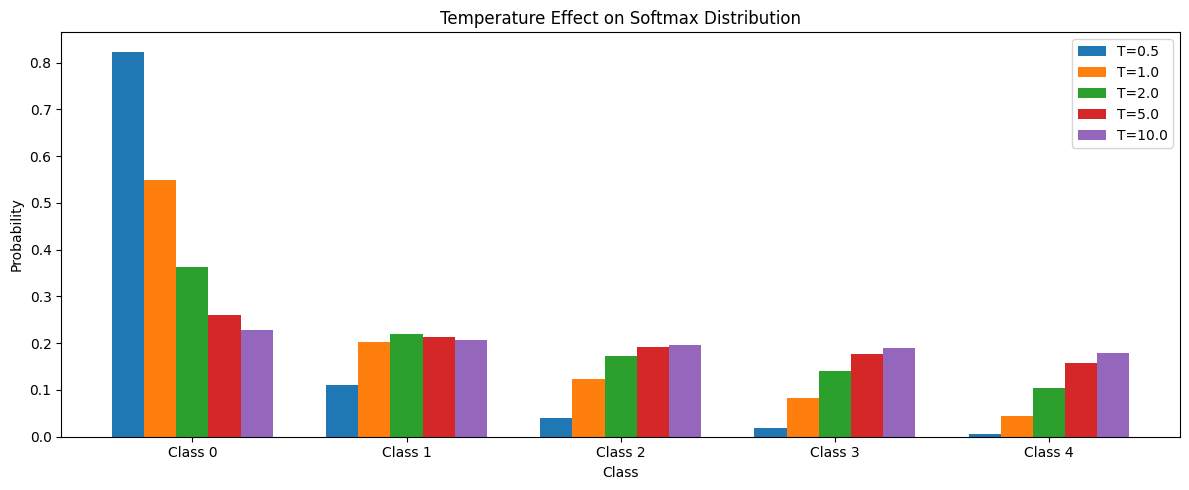

In [5]:
def visualize_temperature_effect():
    """Temperature가 softmax 분포에 미치는 영향 시각화"""
    # 예시 logits
    logits = torch.tensor([2.0, 1.0, 0.5, 0.1, -0.5])
    
    temperatures = [0.5, 1.0, 2.0, 5.0, 10.0]
    
    plt.figure(figsize=(12, 5))
    
    for i, T in enumerate(temperatures):
        probs = torch.softmax(logits / T, dim=0).numpy()
        plt.bar(
            [x + i * 0.15 for x in range(5)], 
            probs, 
            width=0.15, 
            label=f'T={T}'
        )
    
    plt.xlabel('Class')
    plt.ylabel('Probability')
    plt.title('Temperature Effect on Softmax Distribution')
    plt.legend()
    plt.xticks([x + 0.3 for x in range(5)], ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'])
    plt.tight_layout()
    plt.show()

print("[2] Temperature 효과 시각화...")
visualize_temperature_effect()

## 4. 유틸리티 함수 정의

In [6]:
def test(model: nn.Module, test_loader: DataLoader, device: str) -> float:
    """모델 평가"""
    model.to(device)
    model.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy


def train_baseline(
    model: nn.Module,
    train_loader: DataLoader,
    epochs: int,
    learning_rate: float,
    device: str
) -> list[float]:
    """일반 CE 학습"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    model.to(device)
    model.train()
    
    epoch_losses = []
    
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    
    return epoch_losses

## 5. Knowledge Distillation 학습 함수 구현

### KD Loss 수식

```
Loss = soft_target_loss_weight * KD_loss + ce_loss_weight * CE_loss
```

- **KD_loss**: `KL(soft_teacher || soft_student) * T²`
- **CE_loss**: `CrossEntropy(student_logits, labels)`

In [7]:
def train_knowledge_distillation(
    teacher: nn.Module,
    student: nn.Module,
    train_loader: DataLoader,
    epochs: int,
    learning_rate: float,
    T: float,
    soft_target_loss_weight: float,
    ce_loss_weight: float,
    device: str
) -> list[float]:
    """
    Knowledge Distillation 학습
    
    Loss = soft_target_loss_weight * KD_loss + ce_loss_weight * CE_loss
    
    Args:
        teacher: 학습된 Teacher 모델 (weights frozen)
        student: 학습할 Student 모델
        train_loader: 학습 데이터 로더
        epochs: 학습 에포크 수
        learning_rate: 학습률
        T: Temperature (soft target 생성용)
        soft_target_loss_weight: KD loss 가중치
        ce_loss_weight: CE loss 가중치
        device: 학습 디바이스
    
    Returns:
        각 에포크의 평균 loss 리스트
    """
    ce_loss = nn.CrossEntropyLoss()
    optimizer = optim.Adam(student.parameters(), lr=learning_rate)
    
    teacher.to(device)
    student.to(device)
    
    # Teacher는 평가 모드 (weights 고정)
    teacher.eval()
    student.train()
    
    epoch_losses = []
    
    for epoch in range(epochs):
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # Teacher forward pass (no gradient)
            with torch.no_grad():
                teacher_logits = teacher(inputs)
            
            # Student forward pass
            student_logits = student(inputs)
            
            # ===== Soft Target Loss (KD Loss) =====
            # Teacher의 soft targets
            soft_targets = nn.functional.softmax(teacher_logits / T, dim=-1)
            # Student의 soft predictions (log softmax for KL divergence)
            soft_prob = nn.functional.log_softmax(student_logits / T, dim=-1)
            
            # KL Divergence: KL(P || Q) = Σ P * log(P/Q) = Σ P * (log P - log Q)
            # T^2로 스케일링 (gradient 보정)
            soft_targets_loss = torch.sum(
                soft_targets * (soft_targets.log() - soft_prob)
            ) / soft_prob.size(0) * (T ** 2)
            
            # ===== Hard Label Loss (CE Loss) =====
            label_loss = ce_loss(student_logits, labels)
            
            # ===== Combined Loss =====
            loss = soft_target_loss_weight * soft_targets_loss + ce_loss_weight * label_loss
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    
    return epoch_losses

## 6. Teacher 모델 로드

In [8]:
print("\n[3] Teacher 모델 준비...")
teacher = DeepNN(num_classes=NUM_CLASSES).to(DEVICE)

try:
    teacher.load_state_dict(torch.load('./data/trained_models/teacher_model.pth', map_location=DEVICE, weights_only=True))
    print("    저장된 Teacher 모델 로드 완료")
except FileNotFoundError:
    print("    저장된 모델 없음. Teacher 학습 시작...")
    torch.manual_seed(SEED)
    teacher = DeepNN(num_classes=NUM_CLASSES).to(DEVICE)
    train_baseline(teacher, train_loader, EPOCHS, LEARNING_RATE, DEVICE)
    torch.save(teacher.state_dict(), './data/trained_models/teacher_model.pth')

teacher_accuracy = test(teacher, test_loader, DEVICE)


[3] Teacher 모델 준비...
    저장된 Teacher 모델 로드 완료
Test Accuracy: 75.01%


## 7. Student Baseline 학습 (비교용)

KD 없이 일반적인 Cross-Entropy만으로 학습한 Student 모델입니다.

In [9]:
print("\n[4] Student Baseline 학습 (KD 없이)...")
torch.manual_seed(SEED)
student_baseline = LightNN(num_classes=NUM_CLASSES).to(DEVICE)
baseline_losses = train_baseline(student_baseline, train_loader, EPOCHS, LEARNING_RATE, DEVICE)
baseline_accuracy = test(student_baseline, test_loader, DEVICE)


[4] Student Baseline 학습 (KD 없이)...
Epoch 1/10, Loss: 1.4696
Epoch 2/10, Loss: 1.1577
Epoch 3/10, Loss: 1.0257
Epoch 4/10, Loss: 0.9229
Epoch 5/10, Loss: 0.8472
Epoch 6/10, Loss: 0.7802
Epoch 7/10, Loss: 0.7143
Epoch 8/10, Loss: 0.6583
Epoch 9/10, Loss: 0.6051
Epoch 10/10, Loss: 0.5556
Test Accuracy: 70.53%


## 8. Student KD 학습 (Teacher의 지식 전달)

이제 Teacher의 soft targets를 사용하여 Student를 학습합니다.

In [10]:
print("\n[5] Student KD 학습 (Teacher의 지식 전달)...")
print(f"    Temperature: {TEMPERATURE}")
print(f"    Soft Target Loss Weight: {SOFT_TARGET_LOSS_WEIGHT}")
print(f"    CE Loss Weight: {CE_LOSS_WEIGHT}")

torch.manual_seed(SEED)
student_kd = LightNN(num_classes=NUM_CLASSES).to(DEVICE)


[5] Student KD 학습 (Teacher의 지식 전달)...
    Temperature: 2.0
    Soft Target Loss Weight: 0.25
    CE Loss Weight: 0.75


In [11]:
# KD 학습
kd_losses = train_knowledge_distillation(
    teacher=teacher,
    student=student_kd,
    train_loader=train_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    T=TEMPERATURE,
    soft_target_loss_weight=SOFT_TARGET_LOSS_WEIGHT,
    ce_loss_weight=CE_LOSS_WEIGHT,
    device=DEVICE
)

Epoch 1/10, Loss: 2.3356
Epoch 2/10, Loss: 1.8275
Epoch 3/10, Loss: 1.6105
Epoch 4/10, Loss: 1.4434
Epoch 5/10, Loss: 1.3230
Epoch 6/10, Loss: 1.2168
Epoch 7/10, Loss: 1.1208
Epoch 8/10, Loss: 1.0264
Epoch 9/10, Loss: 0.9502
Epoch 10/10, Loss: 0.8809


In [12]:
# KD Student 평가
kd_accuracy = test(student_kd, test_loader, DEVICE)

Test Accuracy: 71.14%


In [13]:
# KD 모델 저장
torch.save(student_kd.state_dict(), './data/trained_models/student_soft_kd.pth')
print("    Student KD 모델 저장: ./data/trained_models/student_soft_kd.pth")

    Student KD 모델 저장: ./data/trained_models/student_soft_kd.pth


## 9. 결과 요약: Soft Target Knowledge Distillation

In [14]:
print("\n" + "=" * 60)
print("결과 요약: Soft Target Knowledge Distillation")
print("=" * 60)
print(f"{'모델':<30} {'정확도':<10}")
print("-" * 60)
print(f"{'Teacher (DeepNN)':<30} {teacher_accuracy:>8.2f}%")
print(f"{'Student Baseline (CE only)':<30} {baseline_accuracy:>8.2f}%")
print(f"{'Student + Soft Target KD':<30} {kd_accuracy:>8.2f}%")
print("-" * 60)

improvement = kd_accuracy - baseline_accuracy
if improvement > 0:
    print(f"KD로 인한 개선: +{improvement:.2f}%")
else:
    print(f"KD 결과: {improvement:.2f}% (개선 없음)")


결과 요약: Soft Target Knowledge Distillation
모델                             정확도       
------------------------------------------------------------
Teacher (DeepNN)                  75.01%
Student Baseline (CE only)        70.53%
Student + Soft Target KD          71.14%
------------------------------------------------------------
KD로 인한 개선: +0.61%


## 10. 학습 곡선 시각화

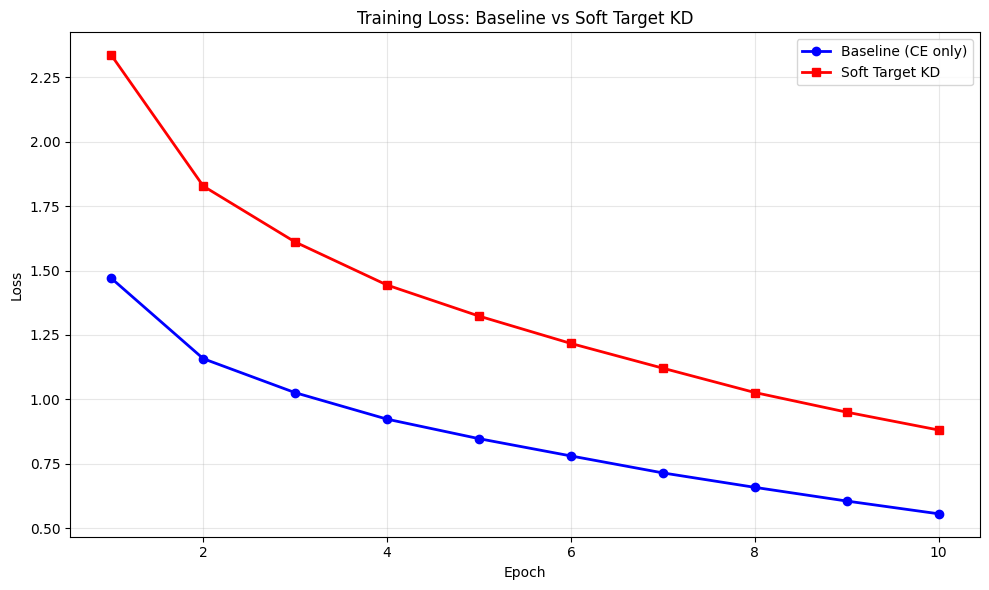

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), baseline_losses, 'b-o', label='Baseline (CE only)', linewidth=2)
plt.plot(range(1, EPOCHS + 1), kd_losses, 'r-s', label='Soft Target KD', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss: Baseline vs Soft Target KD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# 결과 딕셔너리
results = {
    'teacher_accuracy': teacher_accuracy,
    'baseline_accuracy': baseline_accuracy,
    'kd_accuracy': kd_accuracy,
    'kd_losses': kd_losses
}

print("\n결과가 저장되었습니다.")
print("다음 노트북(03_feature_distillation.ipynb)에서 Feature-based KD를 적용해봅니다.")


결과가 저장되었습니다.
다음 노트북(03_feature_distillation.ipynb)에서 Feature-based KD를 적용해봅니다.


---

## 다음 단계

**03_feature_distillation.ipynb**에서는:
1. Cosine Similarity Loss - Hidden Representation 매칭
2. Feature Map + Regressor (FitNets 스타일) - MSE Loss
3. 각 방법의 장단점 비교